/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/3785321436.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


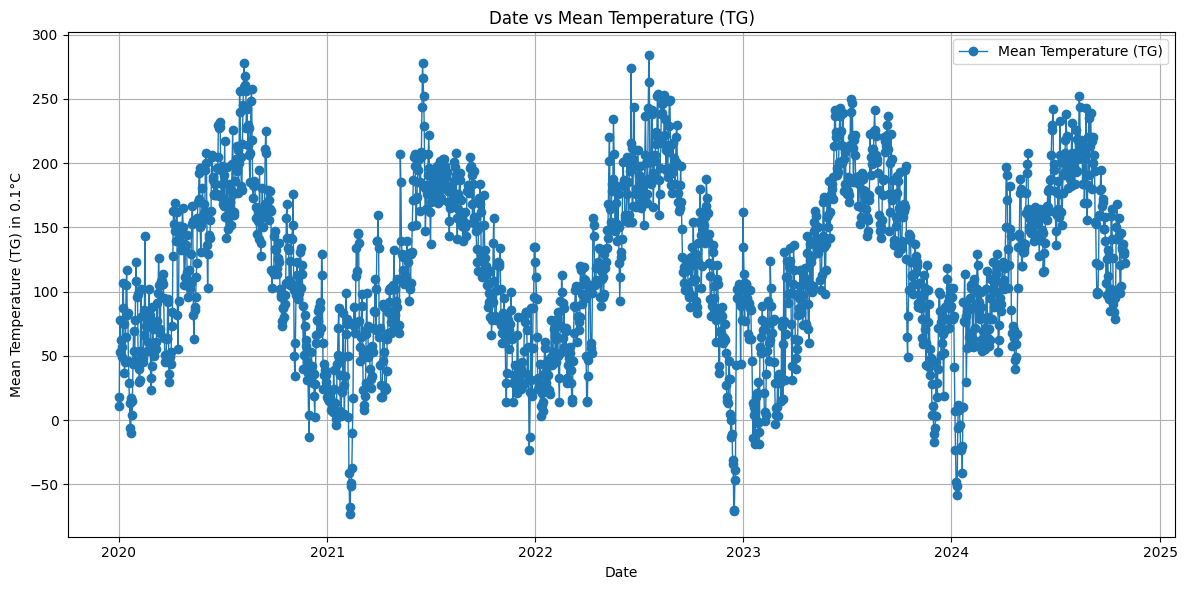

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'TG_SOUID121044.txt'

# Step 1: Read the file and identify data start index
with open(file_path, 'r') as file:
    lines = file.readlines()

data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Step 2: Clean and parse data
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

# Cleaning and organizing data
cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

# Creating a DataFrame from the cleaned data
columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Step 3: Filter out rows where Q_TG equals 9
filtered_data = data_df[data_df["Q_TG"] != 9]

# Step 4: Filter data for entries after 2020
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Step 5: Plot Date vs TG
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.title('Date vs Mean Temperature (TG)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/2411861570.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


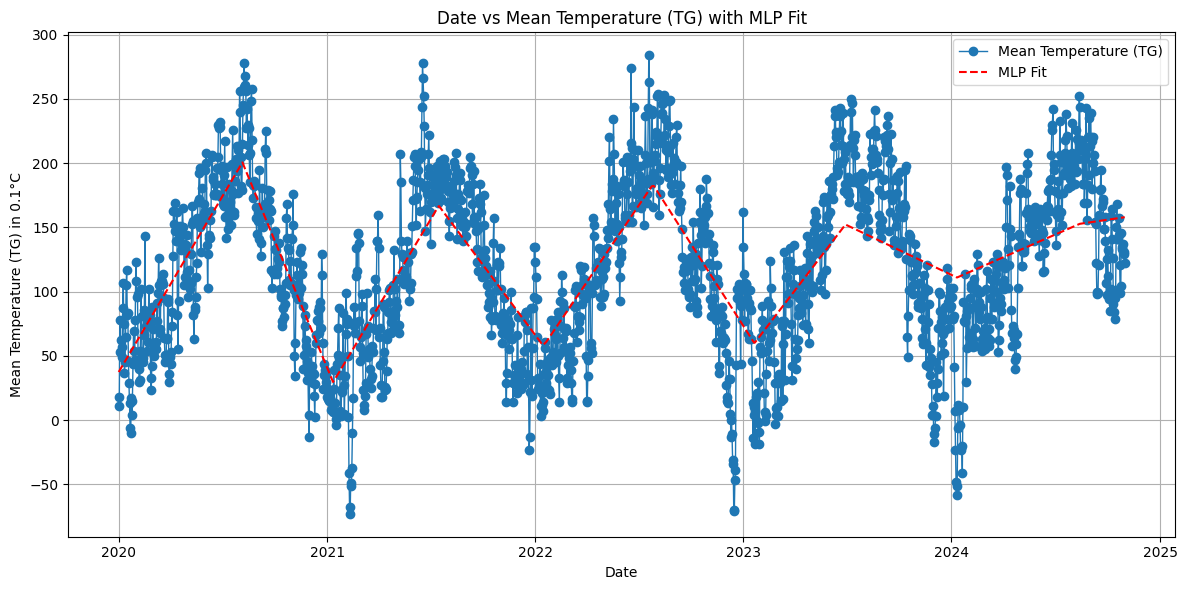

In [23]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TG_SOUID121044.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Mean Temperature (TG) with MLP Fit')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


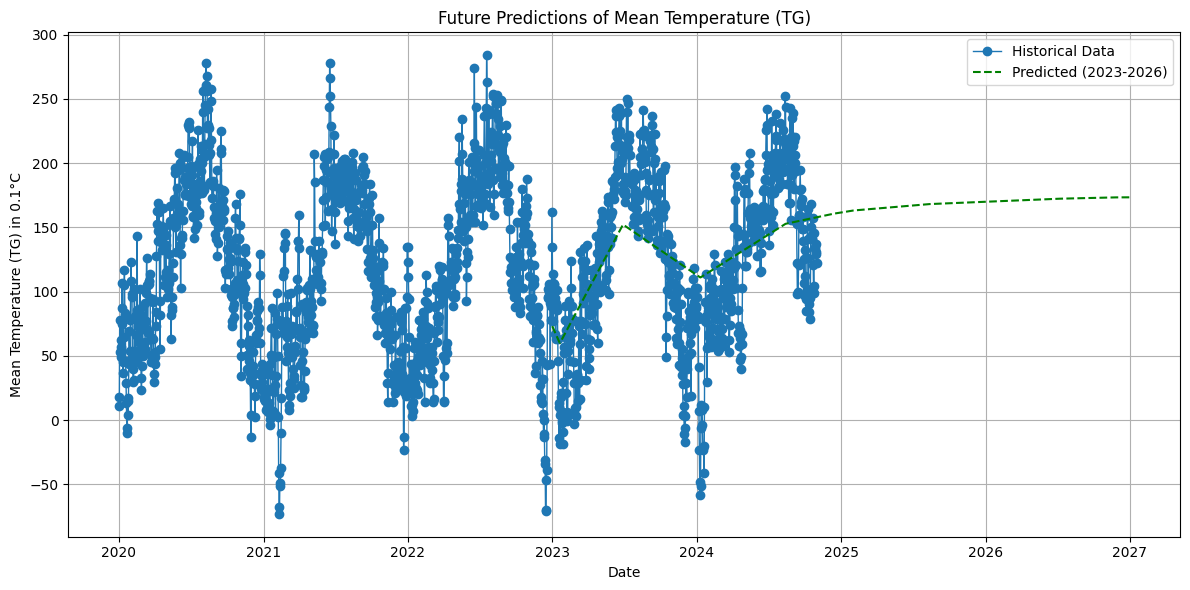

In [24]:
# Cell 7: Predict Future Values (Up to 2026)
future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
X_future_scaled = scaler_X.transform(X_future)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Plot future predictions
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted (2023-2026)', color='green', linestyle='--')
plt.title('Future Predictions of Mean Temperature (TG)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/2031062868.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


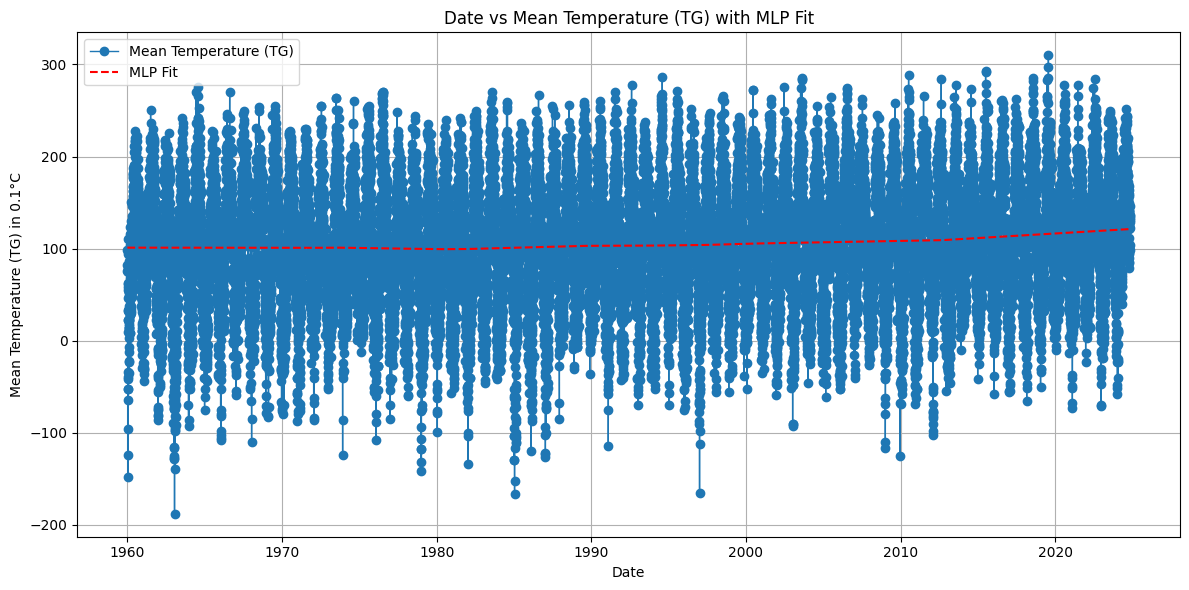

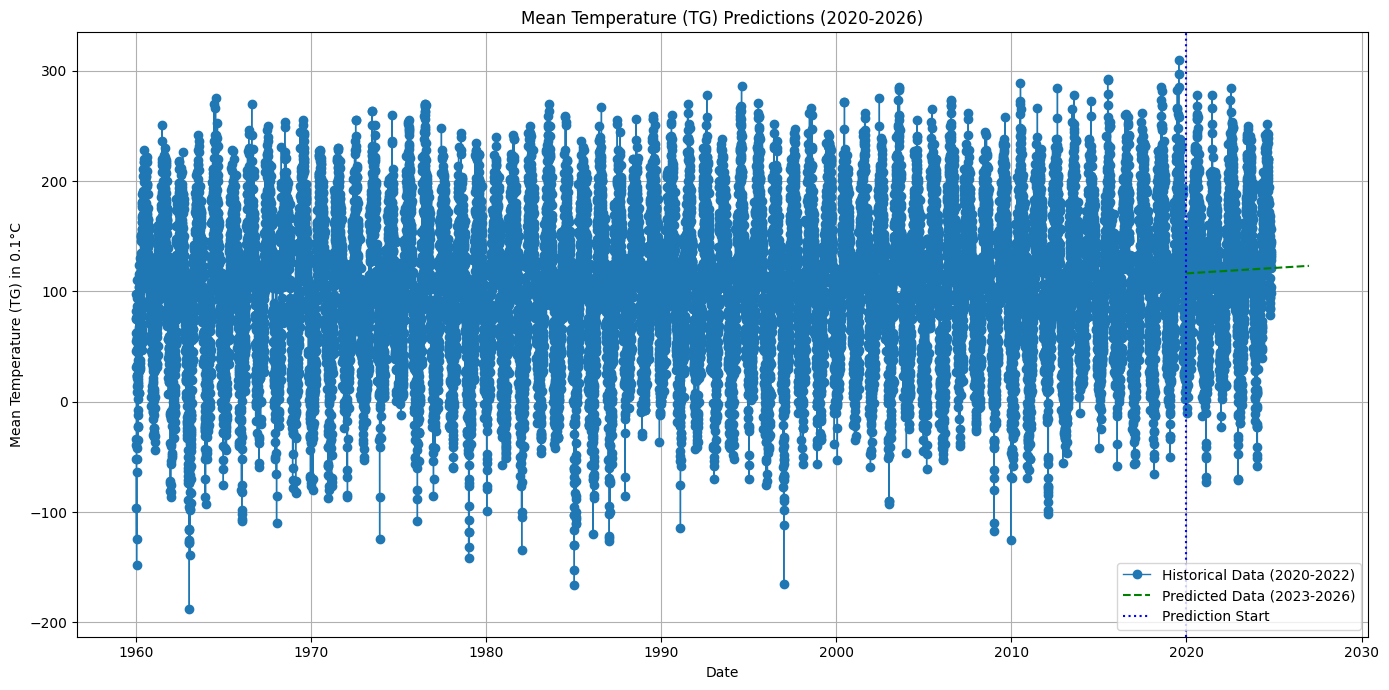

In [25]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TG_SOUID121044.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 19600000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Mean Temperature (TG) with MLP Fit')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026)
# Generate future dates for prediction
future_dates = pd.date_range(start="2020-01-01", end="2026-12-31")
X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
X_future_scaled = scaler_X.transform(X_future)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2022)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2023-2026)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2020-01-01"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Mean Temperature (TG) Predictions (2020-2026)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/512615193.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


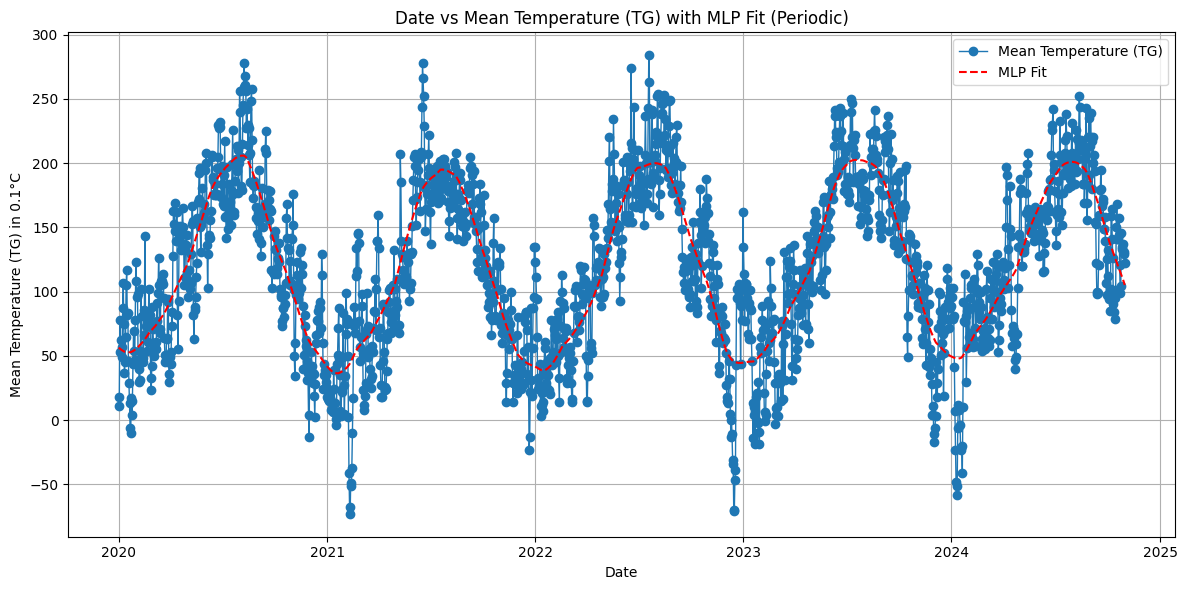

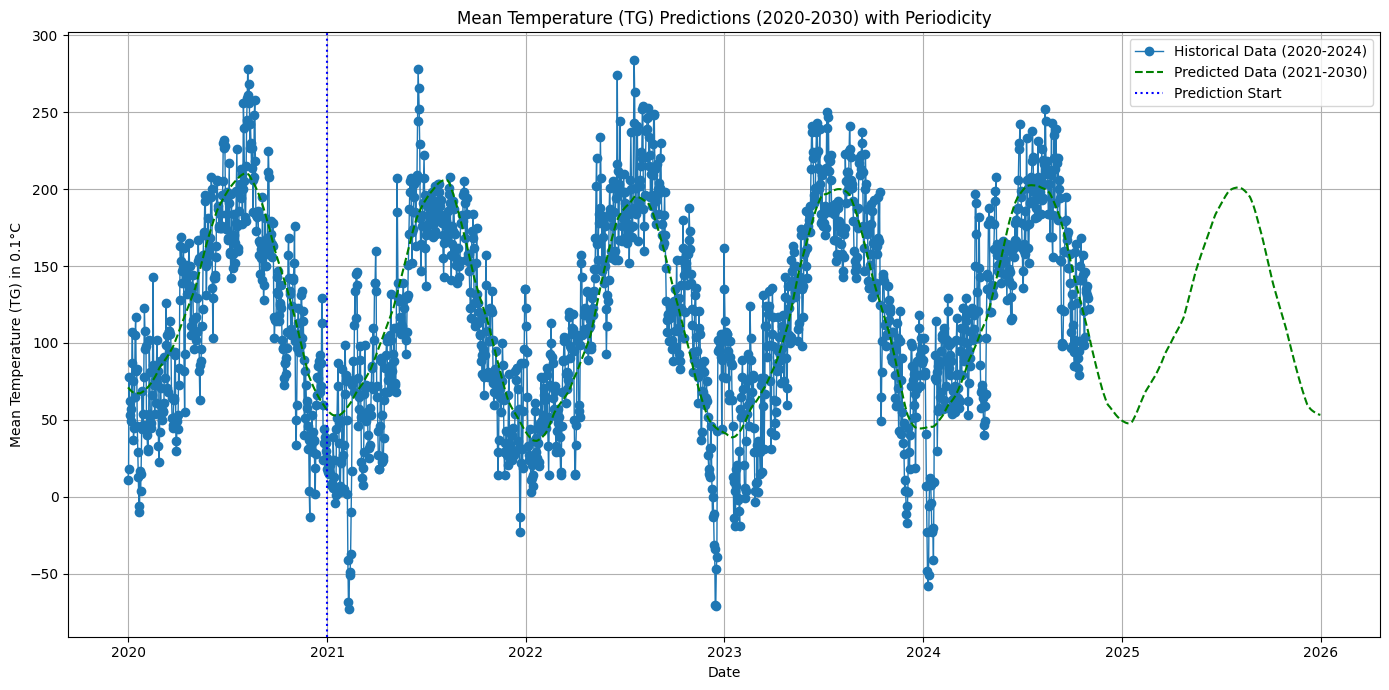

In [30]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TG_SOUID121044.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Mean Temperature (TG) with MLP Fit (Periodic)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2020-01-01", end="2025-12-31")
X_future = (future_dates - pd.Timestamp("2021-01-01")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2021-01-01"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Mean Temperature (TG) Predictions (2020-2030) with Periodicity')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/2054588992.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


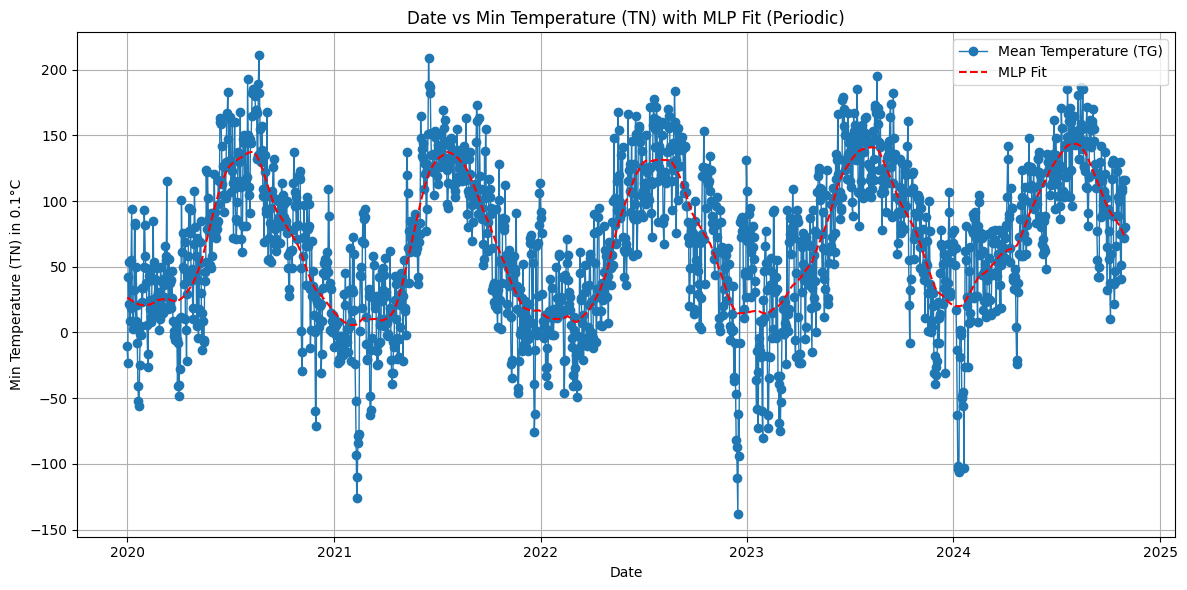

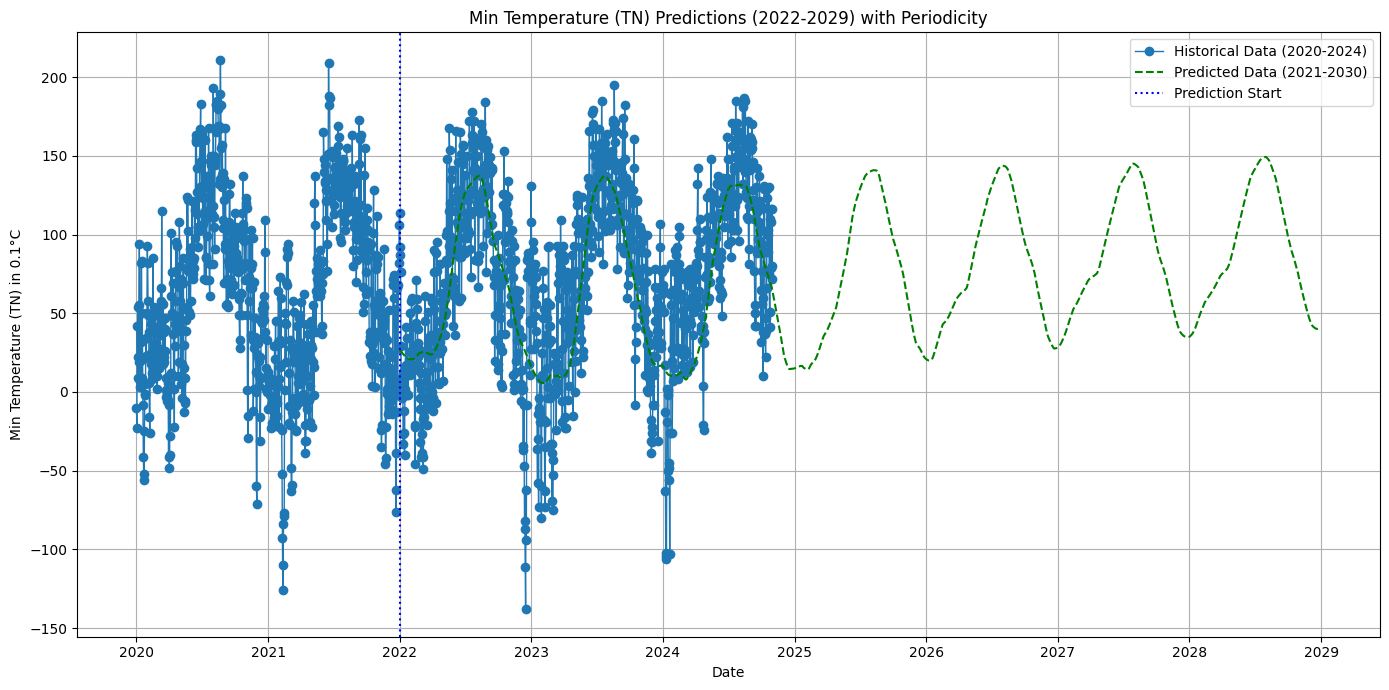

In [35]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TN_SOUID121045.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Min Temperature (TN) with MLP Fit (Periodic)')
plt.xlabel('Date')
plt.ylabel('Min Temperature (TN) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2022-01-01", end="2028-12-31")
X_future = (future_dates - pd.Timestamp("2022-01-01")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2022-01-01"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Min Temperature (TN) Predictions (2022-2029) with Periodicity')
plt.xlabel('Date')
plt.ylabel('Min Temperature (TN) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/2586267585.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


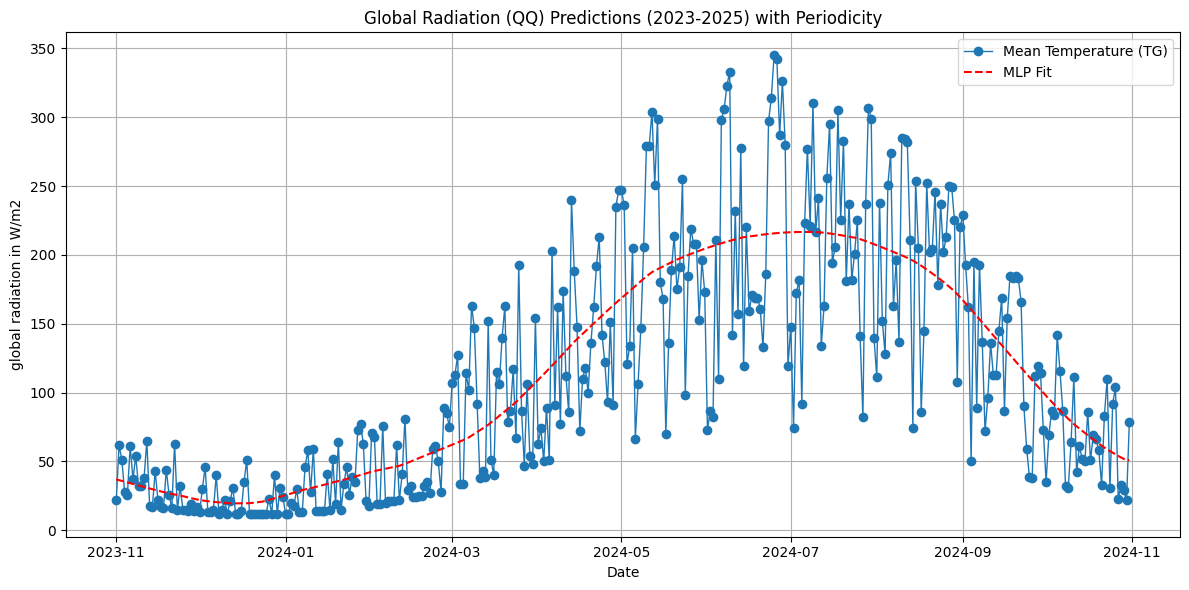

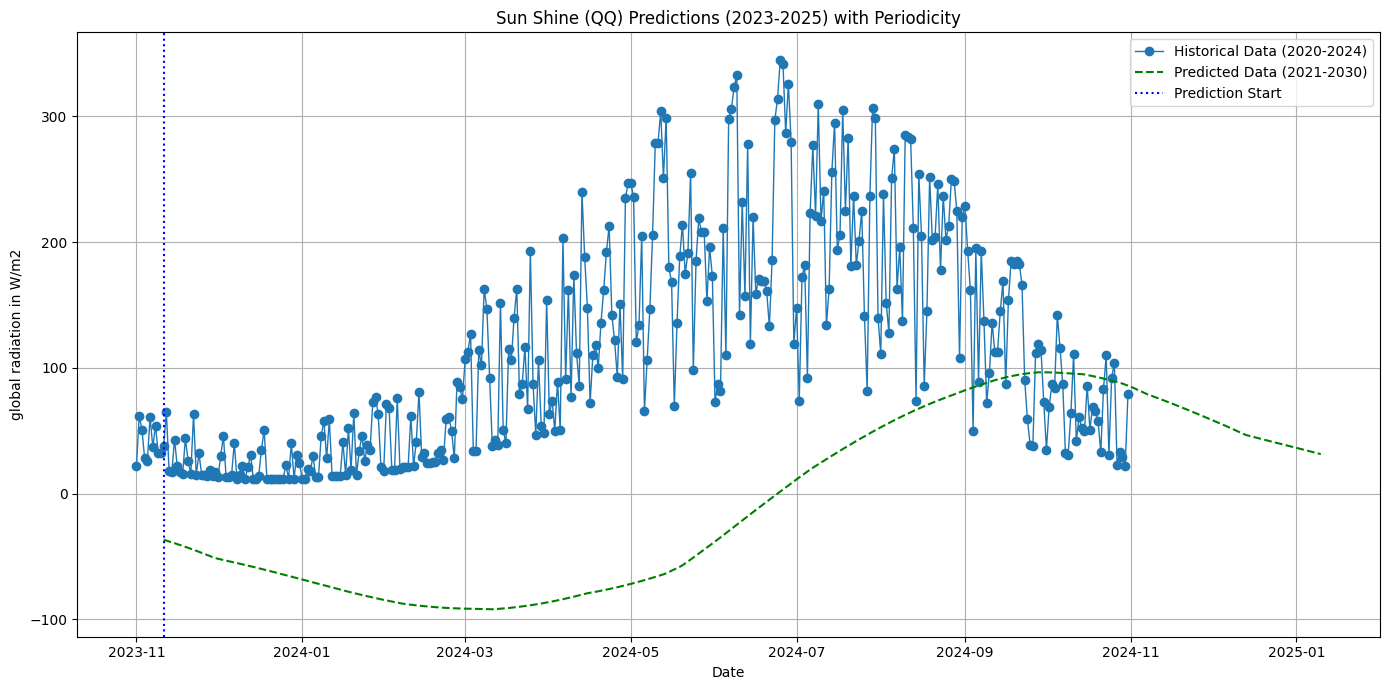

np.float64(48.25060206077949)

In [51]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'QQ_SOUID210447.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20231000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2023-11-11")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Global Radiation (QQ) Predictions (2023-2025) with Periodicity')
plt.xlabel('Date')
plt.ylabel('global radiation in W/m2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2023-11-11", end="2025-01-10")
X_future = (future_dates - pd.Timestamp("2025-01-10")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2023-11-11"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Sun Shine (QQ) Predictions (2023-2025) with Periodicity')
plt.xlabel('Date')
plt.ylabel('global radiation in W/m2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate Percentage Error for the First Graph
# Observed (actual) values
observed_values = filtered_data_after_2020["TG"].values

# Predicted values from the MLP model
predicted_values = y_pred

# Calculate percentage error (Mean Absolute Percentage Error)
percentage_error = np.mean(np.abs((observed_values - predicted_values) / observed_values)) * 100

percentage_error


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/2819674864.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


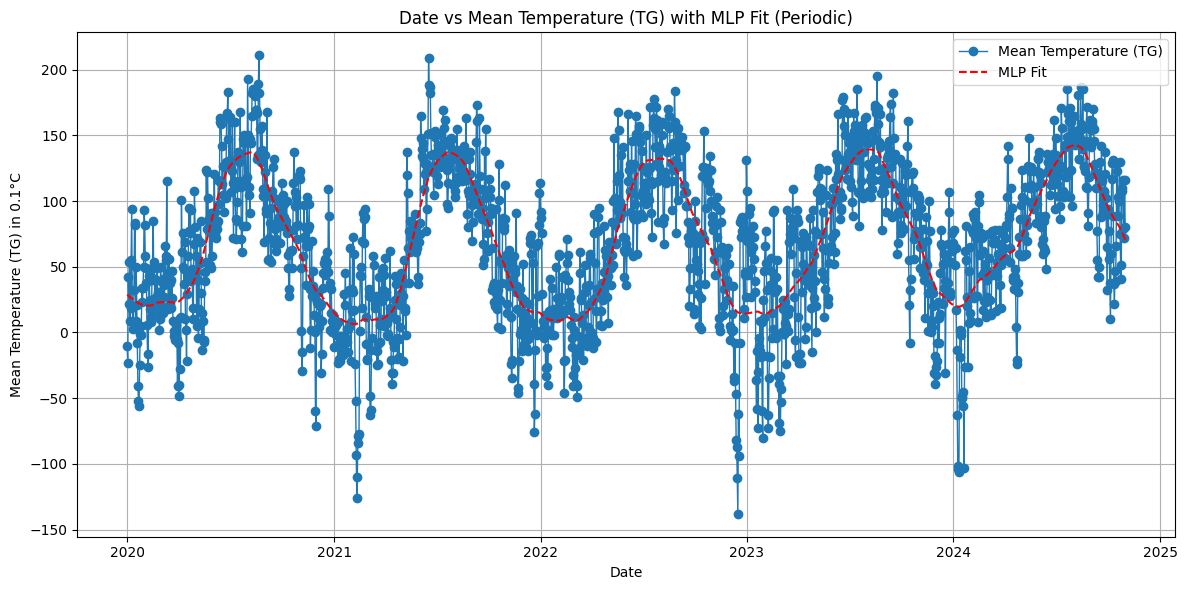

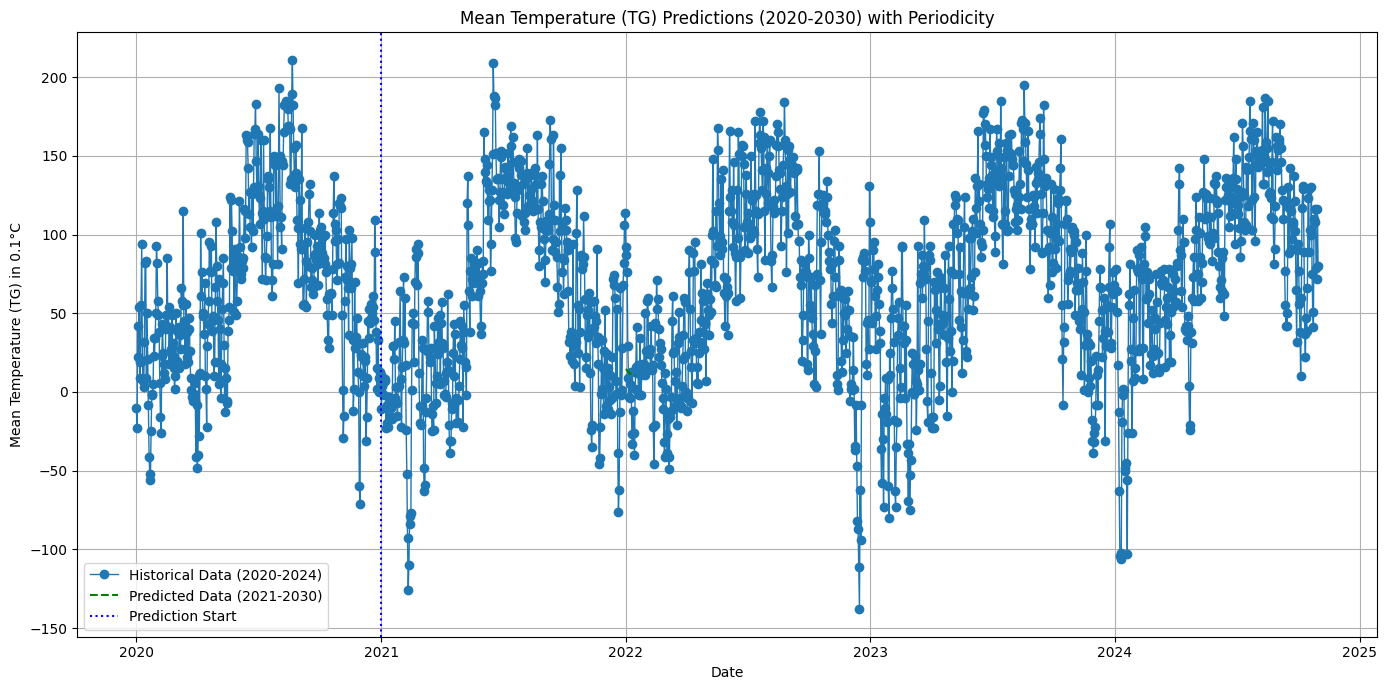

In [34]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TN_SOUID121045.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2022-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Mean Temperature (TG) with MLP Fit (Periodic)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2022-01-01", end="2022-01-15")
X_future = (future_dates - pd.Timestamp("2022-01-01")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2021-01-01"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Mean Temperature (TG) Predictions (2020-2030) with Periodicity')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
# Adjust function to skip both metadata and file headers
def load_and_prepare_corrected(filepath, columns, skiprows=21):
    try:
        df = pd.read_csv(
            filepath,
            skiprows=skiprows,
            header=None,
            names=columns.keys(),
            delimiter=',',  # Adjust delimiter if necessary
        )
        # Keep and rename only the necessary columns
        return df[list(columns.keys())].rename(columns=columns)
    except Exception as e:
        return f"Error loading {filepath}: {str(e)}"

# Reload the "MeanTemp" dataset with corrected function
mean_temp_data_corrected = load_and_prepare_corrected(mean_temp_file, columns_mean_temp)

# Check the output of the loaded data
mean_temp_data_corrected.head() if isinstance(mean_temp_data_corrected, pd.DataFrame) else mean_temp_data_corrected


# Directly convert to numeric and replace invalid values
mean_temp_data_processed['MeanTemp'] = pd.to_numeric(mean_temp_data_processed['MeanTemp'], errors='coerce')

# Filter rows with valid Quality code
mean_temp_data_processed = mean_temp_data_processed[mean_temp_data_processed['Quality'] == 0]

# Drop the Quality column as it's no longer needed
mean_temp_data_processed = mean_temp_data_processed.drop(columns=['Quality'])

# Check the cleaned dataset
mean_temp_data_processed.head()

# Filter data starting from 1960
mean_temp_data_1960 = mean_temp_data_processed[mean_temp_data_processed['DATE'] >= 19600101]

# Check the first few rows of the filtered dataset
mean_temp_data_1960.head()


# Define other key datasets to process and their column mappings
datasets_to_process = {
    "MinTemp": {"filepath": key_files["MinTemp"], "columns": {"SOUID": "SOUID", "DATE": "DATE", "TN": "MinTemp", "Q_TN": "Quality"}},
    "MaxTemp": {"filepath": key_files["MaxTemp"], "columns": {"SOUID": "SOUID", "DATE": "DATE", "TX": "MaxTemp", "Q_TX": "Quality"}},
    "SeaLevelPressure": {"filepath": key_files["SeaLevelPressure"], "columns": {"SOUID": "SOUID", "DATE": "DATE", "PP": "SeaLevelPressure", "Q_PP": "Quality"}},
    "WindSpeed": {"filepath": key_files["WindSpeed"], "columns": {"SOUID": "SOUID", "DATE": "DATE", "FG": "WindSpeed", "Q_FG": "Quality"}},
    "Radiation": {"filepath": key_files["Radiation"], "columns": {"SOUID": "SOUID", "DATE": "DATE", "QQ": "Radiation", "Q_QQ": "Quality"}},
}

# Process and filter each dataset
processed_datasets = {}

for key, info in datasets_to_process.items():
    file_path = os.path.join(extract_dir, info["filepath"])
    processed_data = load_and_prepare_corrected(file_path, info["columns"])
    if isinstance(processed_data, pd.DataFrame):
        # Handle missing values and filter by Quality
        processed_data[info["columns"]["DATE"]] = pd.to_numeric(processed_data[info["columns"]["DATE"]], errors="coerce")
        processed_data[info["columns"]["DATE"]] = processed_data[info["columns"]["DATE"]].fillna(0).astype(int)
        processed_data = processed_data[processed_data["Quality"] == 0]  # Keep only valid rows
        processed_data = processed_data.drop(columns=["Quality"])  # Drop Quality column
        processed_data = processed_data[processed_data["DATE"] >= 19600101]  # Filter data from 1960
        processed_datasets[key] = processed_data

# Check the processed datasets
processed_datasets_summary = {key: df.head() if isinstance(df, pd.DataFrame) else df for key, df in processed_datasets.items()}
processed_datasets_summary


NameError: name 'mean_temp_file' is not defined

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Merge all datasets on the DATE column
merged_data = mean_temp_data_1960.copy()

for key, df in processed_datasets.items():
    if isinstance(df, pd.DataFrame):
        merged_data = pd.merge(merged_data, df, on="DATE", how="inner")

# Check the structure of the merged dataset
merged_data.head()


# Drop redundant SOUID columns
merged_data_cleaned = merged_data.drop(columns=[col for col in merged_data.columns if "SOUID" in col])

# Check the cleaned dataset
merged_data_cleaned.head()

# Prepare features (X) and target (y)
X = merged_data_cleaned.drop(columns=["DATE", "MeanTemp"])  # Features
y = merged_data_cleaned["MeanTemp"]  # Target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
rmse, r2


NameError: name 'mean_temp_data_1960' is not defined

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Function to load and prepare datasets
def load_and_prepare(filepath, columns, skiprows=21):
    df = pd.read_csv(
        filepath, 
        skiprows=skiprows, 
        header=None, 
        names=columns.keys(), 
        delimiter=","  # Adjust delimiter if necessary
    )
    df = df[list(columns.keys())].rename(columns=columns)  # Rename columns
    df[columns["DATE"]] = pd.to_numeric(df[columns["DATE"]], errors="coerce")
    df[columns["DATE"]] = df[columns["DATE"]].fillna(0).astype(int)
    df = df[df["Quality"] == 0].drop(columns=["Quality"])  # Filter valid data
    df = df[df["DATE"] >= 19600101]  # Filter data starting from 1960
    return df

# Example filepaths and column mappings (update these paths as needed)
data_paths = {
    "MeanTemp": {"filepath": "TG_SOUID121044.txt", "columns": {"SOUID": "SOUID", "DATE": "DATE", "TG": "MeanTemp", "Q_TG": "Quality"}},
    "MinTemp": {"filepath": "TN_SOUID121045.txt", "columns": {"SOUID": "SOUID", "DATE": "DATE", "TN": "MinTemp", "Q_TN": "Quality"}},
    "MaxTemp": {"filepath": "TX_SOUID121046.txt", "columns": {"SOUID": "SOUID", "DATE": "DATE", "TX": "MaxTemp", "Q_TX": "Quality"}},
    "SeaLevelPressure": {"filepath": "PP_SOUID121041.txt", "columns": {"SOUID": "SOUID", "DATE": "DATE", "PP": "SeaLevelPressure", "Q_PP": "Quality"}},
    "WindSpeed": {"filepath": "FG_SOUID121048.txt", "columns": {"SOUID": "SOUID", "DATE": "DATE", "FG": "WindSpeed", "Q_FG": "Quality"}},
    "Radiation": {"filepath": "QQ_SOUID210447.txt", "columns": {"SOUID": "SOUID", "DATE": "DATE", "QQ": "Radiation", "Q_QQ": "Quality"}},
}

# Load all datasets
dataframes = {}
for key, info in data_paths.items():
    dataframes[key] = load_and_prepare(info["filepath"], info["columns"])

# Merge datasets on DATE
merged_data = dataframes["MeanTemp"]
for key, df in dataframes.items():
    if key != "MeanTemp":
        merged_data = pd.merge(merged_data, df, on="DATE", how="inner")

# Drop redundant SOUID columns
merged_data = merged_data.drop(columns=[col for col in merged_data.columns if "SOUID" in col])

# Prepare features (X) and target (y)
X = merged_data.drop(columns=["DATE", "MeanTemp"])
y = merged_data["MeanTemp"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}, R2 Score: {r2}")

# Prepare data for visualization
comparison_df = pd.DataFrame({
    "Date": pd.to_datetime(X_test.index, format="%Y%m%d", errors="coerce"),
    "Actual": y_test.values,
    "Predicted": y_pred
}).dropna().sort_values(by="Date")

# Plot actual vs predicted temperatures
plt.figure(figsize=(14, 8))
plt.plot(
    comparison_df["Date"], 
    comparison_df["Actual"] / 10, 
    label="Actual MeanTemp (°C)", 
    color="blue"
)
plt.plot(
    comparison_df["Date"], 
    comparison_df["Predicted"] / 10, 
    label="Predicted MeanTemp (°C)", 
    color="orange"
)
plt.title("Actual vs Predicted Mean Temperature Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Mean Temperature (°C)", fontsize=12)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'TN_SOUID121045.txt'

/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/2401089320.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


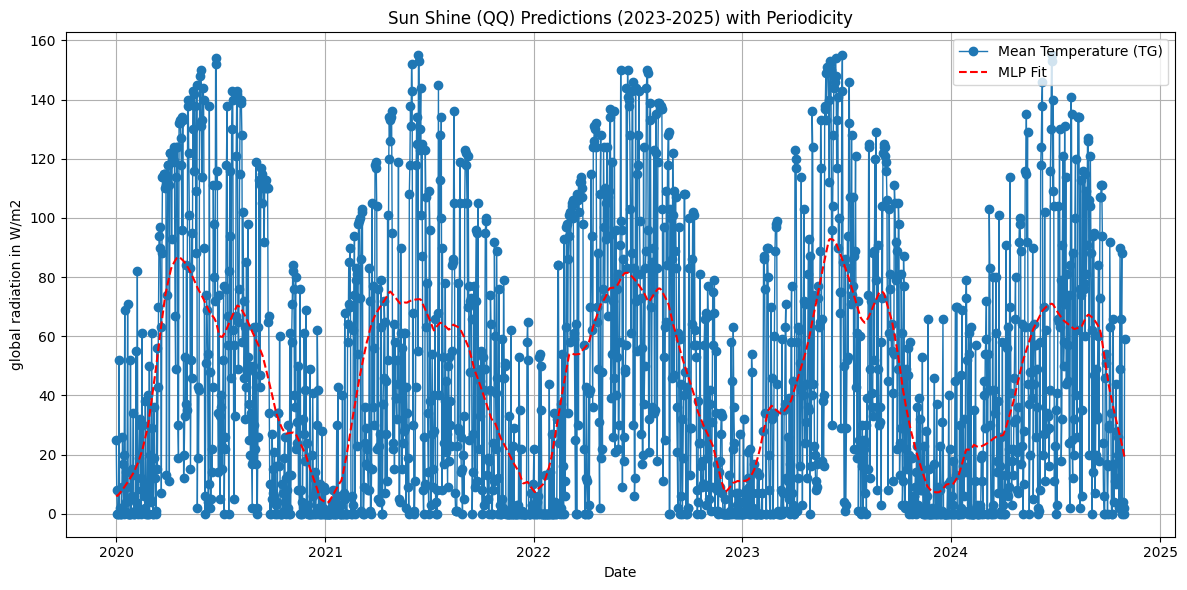

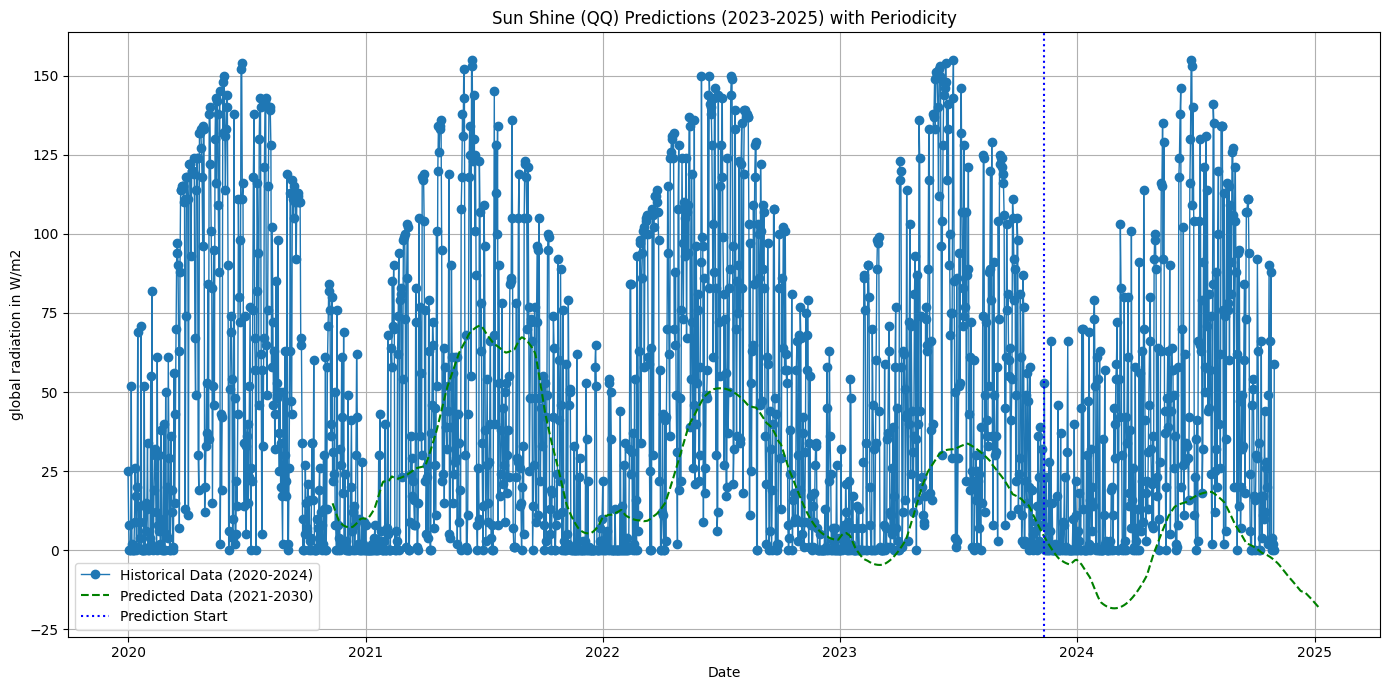

In [49]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'SS_SOUID121040.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2023-11-11")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Sun Shine (QQ) Predictions (2023-2025) with Periodicity')
plt.xlabel('Date')
plt.ylabel('global radiation in W/m2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2020-11-11", end="2025-01-10")
X_future = (future_dates - pd.Timestamp("2020-11-11")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2023-11-11"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Sun Shine (QQ) Predictions (2023-2025) with Periodicity')
plt.xlabel('Date')
plt.ylabel('global radiation in W/m2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
